In [1]:
#librerias 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_parquet("data/listings_clean.parquet")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (76246, 81)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


Ingeniería de características 

Se hace esto para seleccionar las variables que podrían servir par predecir los precios de las propiedades.
las variables relacionadas con la capacidad y el tamaño de alojamiento suelen estar relacionadas con el precio, se seleccionaron las siguientes variables 
accommodates

bedrooms

beds

bathrooms



In [3]:
target = "log_price"

features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms"
]

model_data = df[features + [target]].dropna()

print("Dataset para modelado:", model_data.shape)
model_data.head()

Dataset para modelado: (76032, 5)


,accommodates,bedrooms,beds,bathrooms,log_price
0,3,1.0,2.0,1.0,4.584967
1,2,1.0,2.0,1.0,5.081404
2,2,1.0,1.0,1.0,3.663562
3,3,2.0,2.0,2.0,4.983607
4,2,1.0,1.0,1.0,4.077537


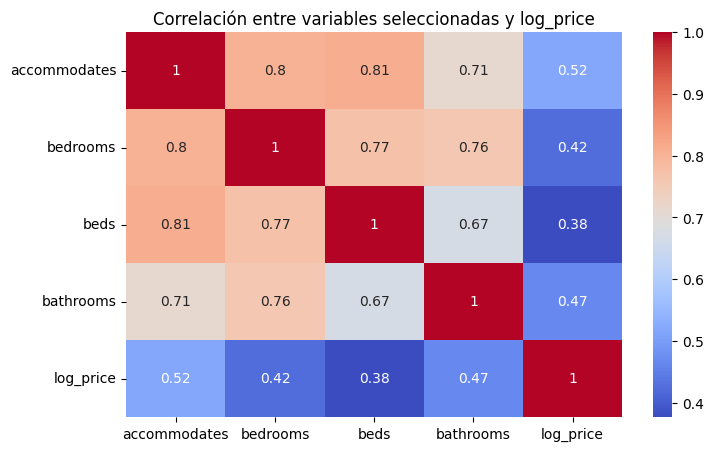

In [4]:
#analisis de correlacion 
corr = model_data.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables seleccionadas y log_price")
plt.show()

In [5]:
# división del dataset

X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (53222, 4)
Prueba: (22810, 4)


In [6]:
# dataset final

train_data = X_train.copy()
train_data[target] = y_train

test_data = X_test.copy()
test_data[target] = y_test

train_data.head()

,accommodates,bedrooms,beds,bathrooms,log_price
24052,3,0.0,2.0,1.0,5.442418
26207,5,1.0,1.0,1.0,5.799093
26355,8,2.0,4.0,2.0,6.291569
56003,6,1.0,1.0,1.0,4.844187
49106,6,3.0,3.0,2.0,6.356108


# Modelo de regresión lineal simple

Se construye un modelo base utilizando `accommodates` como variable explicativa y `log_price` como variable respuesta.

In [7]:
# regresión lineal simple

X_train_simple = X_train[["accommodates"]]
X_test_simple = X_test[["accommodates"]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

y_train_pred_simple = simple_model.predict(X_train_simple)
y_test_pred_simple = simple_model.predict(X_test_simple)

print("Intercepto:", simple_model.intercept_)
print("Coeficiente:", simple_model.coef_[0])

print("\n--- Métricas modelo simple ---")
print("R² train:", r2_score(y_train, y_train_pred_simple))
print("R² test :", r2_score(y_test, y_test_pred_simple))
print("MAE test:", mean_absolute_error(y_test, y_test_pred_simple))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred_simple)))

Intercepto: 4.560368948559677
Coeficiente: 0.17127460181967652

--- Métricas modelo simple ---
R² train: 0.26901320017617425
R² test : 0.2594526674432691
MAE test: 0.5616352357758597
RMSE test: 0.8472056640177423


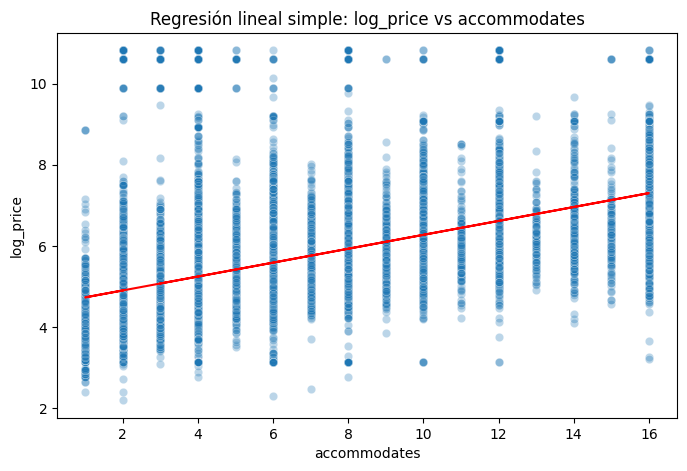

In [8]:
# visualización del modelo simple

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_train_simple["accommodates"], y=y_train, alpha=0.3)
plt.plot(
    X_train_simple["accommodates"],
    y_train_pred_simple,
    color="red"
)
plt.title("Regresión lineal simple: log_price vs accommodates")
plt.xlabel("accommodates")
plt.ylabel("log_price")
plt.show()

# Modelo de regresión lineal múltiple

Se ajusta un modelo de regresión lineal múltiple utilizando las variables numéricas seleccionadas para mejorar la capacidad explicativa respecto al modelo simple.

In [9]:
# regresión lineal múltiple

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

y_train_pred_multiple = multiple_model.predict(X_train)
y_test_pred_multiple = multiple_model.predict(X_test)

print("--- Métricas modelo múltiple ---")
print("R² train:", r2_score(y_train, y_train_pred_multiple))
print("R² test :", r2_score(y_test, y_test_pred_multiple))
print("MAE test:", mean_absolute_error(y_test, y_test_pred_multiple))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred_multiple)))

--- Métricas modelo múltiple ---
R² train: 0.3033995968089329
R² test : 0.28230692459505613
MAE test: 0.5493451248677081
RMSE test: 0.8340302787710421


In [10]:
# coeficientes del modelo múltiple

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": multiple_model.coef_
})

coef_df = coef_df.sort_values(by="Coeficiente", ascending=False)
coef_df

,Variable,Coeficiente
3,bathrooms,0.259657
0,accommodates,0.181856
1,bedrooms,-0.039041
2,beds,-0.100143


# Correlación y multicolinealidad

Se evalúa la posible multicolinealidad entre las variables predictoras mediante la matriz de correlación y el factor de inflación de la varianza (VIF).

In [11]:
# cálculo de VIF

X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Variable,VIF
0,const,4.236212
1,accommodates,4.430301
2,bedrooms,4.160381
3,beds,3.762821
4,bathrooms,2.575637


In [12]:
# resumen estadístico del modelo múltiple

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     5795.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:36:50   Log-Likelihood:                -65498.
No. Observations:               53222   AIC:                         1.310e+05
Df Residuals:                   53217   BIC:                         1.310e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.4237      0.007    598.544   